In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv ('sales_by_month_category.csv',sep=';')
print(df.head())
print(df.info())

     month    categoryname  total_sales
0  1996-07  Dairy Products      9231.70
1  1996-07     Confections      7834.75
2  1996-07         Produce      5204.25
3  1996-07       Beverages      4297.50
4  1996-07         Seafood      3466.55
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   month         64 non-null     object 
 1   categoryname  64 non-null     object 
 2   total_sales   64 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.6+ KB
None


In [8]:
# 3. Общая выручка по категориям (за весь период)
category_total = df.groupby('categoryname')['total_sales'].sum().sort_values(ascending=False)
print("\nВыручка по категориям (всего):")
print(category_total)


Выручка по категориям (всего):
categoryname
Beverages         99464.50
Dairy Products    69921.00
Confections       54909.16
Meat/Poultry      51676.52
Condiments        35071.60
Seafood           29652.30
Produce           23401.40
Grains/Cereals    22327.75
Name: total_sales, dtype: float64


In [9]:
# 4. Сохраняем для графиков
category_total.to_csv('category_totals.csv')

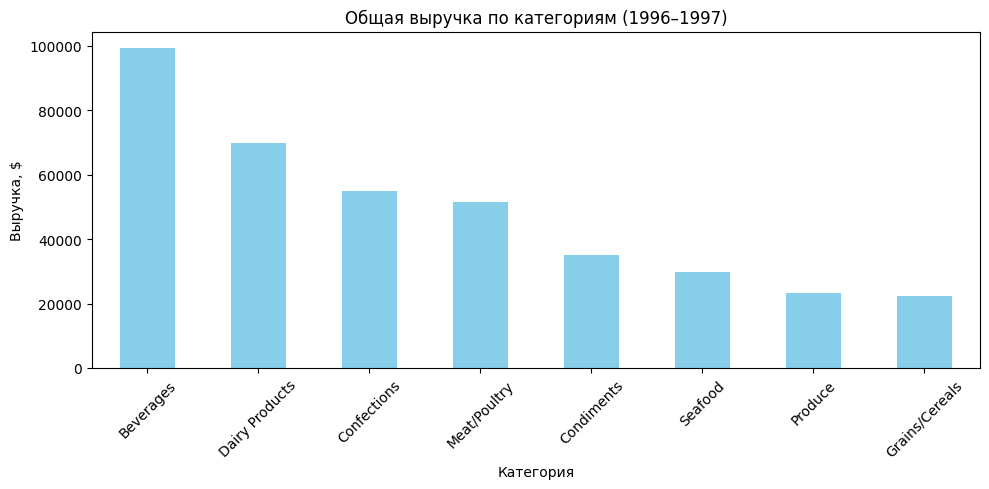

In [11]:
# 5. Столбчатая диаграмма-общая выручка по категориям
plt.figure(figsize=(10,5))
category_total.plot(kind='bar', color='skyblue')
plt.title('Общая выручка по категориям (1996–1997)')
plt.xlabel('Категория')
plt.ylabel('Выручка, $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

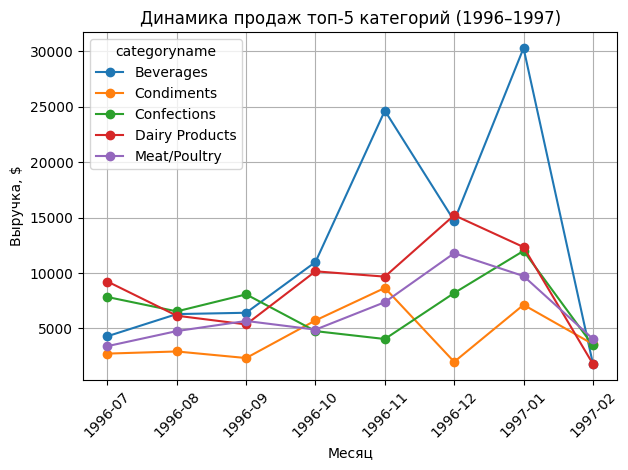

In [12]:
# 6. Динамика продаж-топ 5 самых прибыльных категорий
# Берём 5 самых прибыльных категорий
top_categories = category_total.head(5).index
df_top = df[df['categoryname'].isin(top_categories)]

# Строим сводную таблицу: строки — месяц, столбцы — категория, значения — выручка
pivot = df_top.pivot_table(index='month', columns='categoryname', values='total_sales', aggfunc='sum')

# График
plt.figure(figsize=(12,6))
pivot.plot(marker='o')
plt.title('Динамика продаж топ-5 категорий (1996–1997)')
plt.xlabel('Месяц')
plt.ylabel('Выручка, $')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

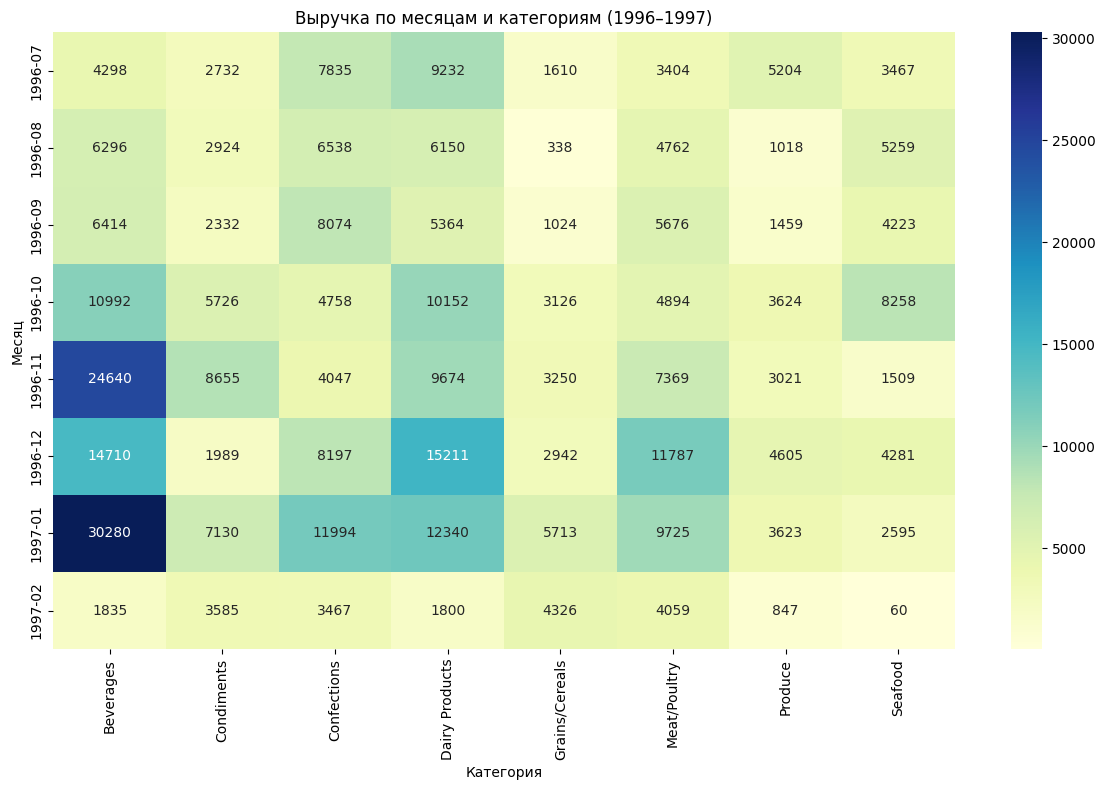

In [14]:
#7 Сводная таблица для тепловой карты
pivot_all = df.pivot_table(index='month', columns='categoryname', values='total_sales', aggfunc='sum').fillna(0)
#Тепловая карта
plt.figure(figsize=(12,8))
sns.heatmap(pivot_all, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Выручка по месяцам и категориям (1996–1997)')
plt.xlabel('Категория')
plt.ylabel('Месяц')
plt.tight_layout()
plt.show()